# 🧱 JSON Flattener

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/data-engineering-pro/json-flattener/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=data-engineering-pro/json-flattener/demo.ipynb)

**Every API response is nested. Every warehouse table is flat.**

The gap gets closed by hand-written, one-off unnesting code that breaks the first time a field is
missing or an array changes length. This notebook builds a flattener that takes an explicit
position on the two decisions that actually break pipelines - and then demonstrates, with a
number, the silent bug that hand-rolled unnesting almost always ships.

### What this notebook covers
1. The two decisions: arrays and missing keys
2. Flattening one record - dot paths, three array modes
3. Ragged records: why the column set is a UNION, not an intersection
4. **The fan-out trap** - revenue reads 539.00 when the truth is 450.00
5. Pinning the grain to fix it
6. Type conflicts - the failure that hits at load time, not flatten time
7. Inferred DDL so the shape can be landed
8. Chart: rows, columns and correctness across modes
9. Try your own payload

## Step 1 - The two decisions

Flattening looks mechanical until you hit these, and both have to be *chosen*, not defaulted:

**Arrays.** Three defensible answers, and they produce different tables:

| Mode | Shape | When it's right |
|---|---|---|
| `explode` | one row per element | the array is a set of facts (order items) |
| `index` | one column per element (`items.0.sku`) | fixed, small arity (`coords.0`, `coords.1`) |
| `json` | one column, array kept whole | the array is a payload you'll query later, not a fact |

**Missing keys.** Real records are ragged. The column set is the **union** across all records,
with nulls where a record didn't have the path - because an intersection would silently drop the
optional fields, and an error would reject normal data.

In [1]:
from __future__ import annotations

import json
from collections import Counter
from dataclasses import dataclass, field
from typing import Any, Dict, List

SEP = "."
_SCALARS = (str, int, float, bool, type(None))

SAMPLE_ORDERS: List[Dict[str, Any]] = [
    {
        "order_id": "A-1001",
        "placed_at": "2026-07-28T09:12:00Z",
        "customer": {"id": 552, "name": "Nadia",
                     "address": {"city": "Singapore", "zip": "018956"}},
        "items": [
            {"sku": "KB-01", "qty": 1, "price": 89.0, "tags": ["input", "wireless"]},
            {"sku": "MS-07", "qty": 2, "price": 25.5, "tags": ["input"]},
        ],
        "total": 140.0,
        "coupon": None,
    },
    {   # ragged: no address.zip, no coupon key at all, extra channel field
        "order_id": "A-1002",
        "placed_at": "2026-07-28T10:03:00Z",
        "customer": {"id": 771, "name": "Wei", "address": {"city": "Kuala Lumpur"}},
        "items": [{"sku": "MN-27", "qty": 1, "price": 310.0, "tags": []}],
        "total": 310.0,
        "channel": "mobile",
    },
    {   # type conflict: total arrives as a string from a different producer
        "order_id": "A-1003",
        "placed_at": "2026-07-29T14:40:00Z",
        "customer": {"id": 552, "name": "Nadia",
                     "address": {"city": "Singapore", "zip": "018956"}},
        "items": [],
        "total": "0.00",
        "coupon": "WELCOME10",
    },
]

print(f"{len(SAMPLE_ORDERS)} records")
print("record 2 is missing:", {"customer.address.zip", "coupon"} )
print("record 2 adds:", {"channel"})
print("record 3 total type:", type(SAMPLE_ORDERS[2]["total"]).__name__, "(others: float)")

3 records
record 2 is missing: {'customer.address.zip', 'coupon'}
record 2 adds: {'channel'}
record 3 total type: str (others: float)


## Step 2 - Flatten one record

Recursive walk. Dicts extend the path, scalars become values, arrays branch according to the
mode. The one subtlety worth calling out: an **empty array** keeps the record as a row with nulls
in the array's columns (`explode_outer` semantics) instead of dropping it - and deliberately does
*not* create a scalar column for the array path itself, because that would collide with the
`items.sku` columns other records produce and leave a half-typed wart in the DDL.

In [2]:
def flatten_record(record, array_mode="explode", sep=SEP, max_array_cols=20,
                   explode_paths=None):
    if array_mode not in ("explode", "index", "json"):
        raise ValueError("array_mode must be 'explode', 'index' or 'json'")
    allowed = None if explode_paths is None else set(explode_paths)

    def assign(rows_in, key, value):
        for r in rows_in:
            r[key] = value
        return rows_in

    def walk(obj, prefix, rows_in):
        if isinstance(obj, dict):
            if not obj:
                return assign(rows_in, prefix or "_root", None)
            out = rows_in
            for k, v in obj.items():
                out = walk(v, f"{prefix}{sep}{k}" if prefix else str(k), out)
            return out

        if isinstance(obj, list):
            if not obj:
                # keep the row, null the array's columns; no scalar column for `prefix`
                return assign(rows_in, prefix, None) if array_mode == "json" else rows_in
            keep_whole = array_mode == "json" or (
                array_mode == "explode" and allowed is not None and prefix not in allowed)
            if keep_whole:
                return assign(rows_in, prefix, json.dumps(obj))
            if array_mode == "index":
                out = rows_in
                for i, item in enumerate(obj[:max_array_cols]):
                    out = walk(item, f"{prefix}{sep}{i}", out)
                if len(obj) > max_array_cols:
                    out = assign(out, f"{prefix}{sep}_truncated_count",
                                 len(obj) - max_array_cols)
                return out
            exploded = []
            for item in obj:                       # cross the rows with the elements
                exploded.extend(walk(item, prefix, [dict(r) for r in rows_in]))
            return exploded

        return assign(rows_in, prefix, obj)

    return walk(record, "", [{}])


for mode in ("explode", "index", "json"):
    rows = flatten_record(SAMPLE_ORDERS[0], array_mode=mode)
    print(f"{mode:>8}: {len(rows)} row(s), {len(rows[0])} columns")
print()
print("explode, first row keys:")
print(" ", list(flatten_record(SAMPLE_ORDERS[0])[0].keys()))

 explode: 3 row(s), 12 columns
   index: 1 row(s), 17 columns
    json: 1 row(s), 9 columns

explode, first row keys:
  ['order_id', 'placed_at', 'customer.id', 'customer.name', 'customer.address.city', 'customer.address.zip', 'items.sku', 'items.qty', 'items.price', 'items.tags', 'total', 'coupon']


## Step 3 - Many records: union the columns, count the raggedness

Reporting *how many* records were missing each path is the part that earns its keep. A path
missing in 3 of 10,000 records is an optional field; a path missing in 6,000 is a schema change
somebody forgot to mention.

In [3]:
@dataclass
class FlattenStats:
    input_records: int = 0
    output_rows: int = 0
    columns: int = 0
    max_depth: int = 0
    exploded_paths: List[str] = field(default_factory=list)
    ragged_paths: Dict[str, int] = field(default_factory=dict)
    type_conflicts: Dict[str, List[str]] = field(default_factory=dict)

    @property
    def row_multiplier(self):
        return round(self.output_rows / self.input_records, 2) if self.input_records else 0.0

    @property
    def fanout_warning(self):
        """Two exploded paths where one nests in the other = a cross join happened."""
        nested = [(a, b) for a in self.exploded_paths for b in self.exploded_paths
                  if a != b and b.startswith(a + SEP)]
        if not nested:
            return None
        a, b = nested[0]
        return (f"'{b}' exploded inside '{a}' - every scalar on '{a}' repeats once per "
                f"'{b}' element, so SUM() over it double-counts. "
                f"Pass explode_paths=['{a}'] to pin the grain.")


def _depth(obj, current=0):
    if isinstance(obj, dict):
        return max([_depth(v, current + 1) for v in obj.values()] or [current])
    if isinstance(obj, list):
        return max([_depth(v, current + 1) for v in obj] or [current])
    return current


def _array_paths(obj, sep=SEP, prefix=""):
    if isinstance(obj, dict):
        for k, v in obj.items():
            yield from _array_paths(v, sep, f"{prefix}{sep}{k}" if prefix else str(k))
    elif isinstance(obj, list):
        yield (prefix, len(obj))
        for item in obj:
            yield from _array_paths(item, sep, prefix)


def _type_conflicts(rows):
    kinds = {}
    for r in rows:
        for k, v in r.items():
            if v is not None:
                kinds.setdefault(k, set()).add(type(v).__name__)
    return {k: sorted(v) for k, v in kinds.items() if len(v) > 1}


def flatten(records, array_mode="explode", sep=SEP, max_array_cols=20, explode_paths=None):
    stats = FlattenStats(input_records=len(records))
    all_rows, per_record_paths = [], []
    for rec in records:
        stats.max_depth = max(stats.max_depth, _depth(rec))
        if array_mode == "explode":
            for path, length in _array_paths(rec, sep):
                if explode_paths is not None and path not in set(explode_paths):
                    continue
                if length > 1 and path not in stats.exploded_paths:
                    stats.exploded_paths.append(path)
        rows = flatten_record(rec, array_mode, sep, max_array_cols, explode_paths)
        all_rows.extend(rows)
        paths = set()
        for r in rows:
            paths |= set(r.keys())
        per_record_paths.append(paths)

    union, seen = [], set()          # UNION of columns, first-seen order
    for r in all_rows:
        for k in r:
            if k not in seen:
                seen.add(k)
                union.append(k)
    for path in union:
        missing = sum(1 for p in per_record_paths if path not in p)
        if missing:
            stats.ragged_paths[path] = missing

    normalised = [{k: r.get(k) for k in union} for r in all_rows]
    stats.output_rows, stats.columns = len(normalised), len(union)
    stats.type_conflicts = _type_conflicts(normalised)
    return normalised, stats


import pandas as pd

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)

for mode in ("explode", "index", "json"):
    rows, st = flatten(SAMPLE_ORDERS, array_mode=mode)
    print(f"{mode:>8}: {st.input_records} records -> {st.output_rows} rows "
          f"({st.row_multiplier}x), {st.columns} cols, depth {st.max_depth}")

rows, st = flatten(SAMPLE_ORDERS)
print("\nragged paths (rows missing the path):")
for p, n in sorted(st.ragged_paths.items(), key=lambda kv: -kv[1]):
    print(f"  {p:<26} {n} of {st.output_rows}")

 explode: 3 records -> 5 rows (1.67x), 13 cols, depth 4
   index: 3 records -> 3 rows (1.0x), 18 cols, depth 4
    json: 3 records -> 3 rows (1.0x), 10 cols, depth 4

ragged paths (rows missing the path):
  items.tags                 2 of 5
  channel                    2 of 5
  customer.address.zip       1 of 5
  items.sku                  1 of 5
  items.qty                  1 of 5
  items.price                1 of 5
  coupon                     1 of 5


## Step 4 - The fan-out trap

Here is the bug. Flatten the orders with the obvious default - explode every array - and then do
the most natural thing in the world: sum the revenue.

In [4]:
truth = sum(it["price"] * it["qty"] for o in SAMPLE_ORDERS for it in o.get("items", []))

rows_all, st_all = flatten(SAMPLE_ORDERS, array_mode="explode")
revenue_all = sum((r["items.price"] or 0) * (r["items.qty"] or 0) for r in rows_all)

print(f"ground truth revenue        : {truth:.2f}")
print(f"after explode-everything    : {revenue_all:.2f}   <- off by {revenue_all - truth:+.2f}")
print(f"rows                        : {st_all.output_rows} from {st_all.input_records} records")
print(f"exploded paths              : {st_all.exploded_paths}")
print()
print(pd.DataFrame(rows_all)[["order_id", "items.sku", "items.qty", "items.price",
                             "items.tags"]].to_string(index=False))

ground truth revenue        : 450.00
after explode-everything    : 539.00   <- off by +89.00
rows                        : 5 from 3 records
exploded paths              : ['items', 'items.tags']

order_id items.sku  items.qty  items.price items.tags
  A-1001     KB-01        1.0         89.0      input
  A-1001     KB-01        1.0         89.0   wireless
  A-1001     MS-07        2.0         25.5      input
  A-1002     MN-27        1.0        310.0       None
  A-1003      None        NaN          NaN       None


Look at `KB-01`. It appears **twice**, identically - once for each of its two `tags`. Exploding
the nested `items.tags` array multiplied the rows of its parent, so the item's price got counted
twice. Revenue reads 539.00 when the truth is 450.00.

Nothing errored. No null appeared. The row count went up by a plausible-looking amount. This is
the single most common silent bug in hand-rolled unnesting code, and it is invisible unless you
happen to reconcile the total against the source.

The stats object catches it structurally - two exploded paths where one is a prefix of the other
*is* a cross join:

In [5]:
print(st_all.fanout_warning)

'items.tags' exploded inside 'items' - every scalar on 'items' repeats once per 'items.tags' element, so SUM() over it double-counts. Pass explode_paths=['items'] to pin the grain.


## Step 5 - Pin the grain

The fix is to say what one row means. `explode_paths=["items"]` gives one row per item and keeps
`tags` whole as JSON - queryable later, harmless now.

In [6]:
rows_pin, st_pin = flatten(SAMPLE_ORDERS, array_mode="explode", explode_paths=["items"])
revenue_pin = sum((r["items.price"] or 0) * (r["items.qty"] or 0) for r in rows_pin)

print(f"{'mode':<28}{'rows':>6}{'revenue':>10}   verdict")
print("-" * 62)
print(f"{'explode everything':<28}{st_all.output_rows:>6}{revenue_all:>10.2f}   "
      f"WRONG (+{revenue_all - truth:.2f})")
print(f"{'explode_paths=[items]':<28}{st_pin.output_rows:>6}{revenue_pin:>10.2f}   "
      f"{'OK' if abs(revenue_pin - truth) < 1e-9 else 'wrong'}")
print(f"\nfan-out warning after pinning: {st_pin.fanout_warning}")
print()
print(pd.DataFrame(rows_pin)[["order_id", "items.sku", "items.qty", "items.price",
                             "items.tags"]].to_string(index=False))

mode                          rows   revenue   verdict
--------------------------------------------------------------
explode everything               5    539.00   WRONG (+89.00)
explode_paths=[items]            4    450.00   OK

fan-out warning after pinning: None

order_id items.sku  items.qty  items.price            items.tags
  A-1001     KB-01        1.0         89.0 ["input", "wireless"]
  A-1001     MS-07        2.0         25.5             ["input"]
  A-1002     MN-27        1.0        310.0                  None
  A-1003      None        NaN          NaN                  None


Four rows, one per item, and the empty-array order (`A-1003`) survives as a row with nulls
instead of vanishing. Revenue is exact.

## Step 6 - Type conflicts and the DDL

`total` is a float in two records and the string `"0.00"` in the third - a different producer,
a different serialiser. This is the failure that hits at **load** time, not flatten time: a
column that is numeric in 9,000 rows and text in 3 rejects the entire batch.

The schema inference makes two deliberate calls:

- **int + float is a widening, not a conflict.** A column with both is a `DOUBLE`. Treating that
  as an error would fail perfectly valid data.
- **A genuine conflict widens to VARCHAR and is annotated** rather than dropping rows. The load
  succeeds; the problem stays visible in the DDL comment.

In [7]:
_SQL_TYPE = {"bool": "BOOLEAN", "int": "BIGINT", "float": "DOUBLE",
             "str": "VARCHAR", "NoneType": "VARCHAR"}


def infer_schema(rows):
    if not rows:
        return []
    out = []
    for c in rows[0].keys():
        vals = [r.get(c) for r in rows]
        present = [v for v in vals if v is not None]
        types = Counter(type(v).__name__ for v in present)
        names = set(types)
        if names <= {"int", "float"} and names:
            py = "float" if "float" in names else "int"   # widening, not a conflict
        elif len(names) > 1:
            py = "str"                                    # genuine conflict -> widen to text
        else:
            py = next(iter(names), "NoneType")
        out.append({"column": c, "python_type": py, "sql_type": _SQL_TYPE.get(py, "VARCHAR"),
                    "nullable": len(present) < len(vals),
                    "fill_rate": round(len(present) / len(vals), 3),
                    "mixed_types": ",".join(sorted(types)) if len(types) > 1 else ""})
    return out


def to_ddl(rows, table="flattened"):
    schema = infer_schema(rows)
    lines = [f"CREATE TABLE {table} ("]
    for i, s in enumerate(schema):
        comma = "," if i < len(schema) - 1 else ""
        null = "" if s["nullable"] else " NOT NULL"
        note = f"  -- mixed: {s['mixed_types']}" if s["mixed_types"] else ""
        lines.append(f'  "{s["column"]}" {s["sql_type"]}{null}{comma}{note}')
    return "\n".join(lines + [");"])


print("type conflicts:", st_pin.type_conflicts)
print()
print(pd.DataFrame(infer_schema(rows_pin)).to_string(index=False))
print()
print(to_ddl(rows_pin, "orders_flat"))

type conflicts: {'total': ['float', 'str']}

               column python_type sql_type  nullable  fill_rate mixed_types
             order_id         str  VARCHAR     False       1.00            
            placed_at         str  VARCHAR     False       1.00            
          customer.id         int   BIGINT     False       1.00            
        customer.name         str  VARCHAR     False       1.00            
customer.address.city         str  VARCHAR     False       1.00            
 customer.address.zip         str  VARCHAR      True       0.75            
            items.sku         str  VARCHAR      True       0.75            
            items.qty         int   BIGINT      True       0.75            
          items.price       float   DOUBLE      True       0.75            
           items.tags         str  VARCHAR      True       0.50            
                total         str  VARCHAR     False       1.00   float,str
               coupon         str  VARCHAR 

## Step 7 - The picture

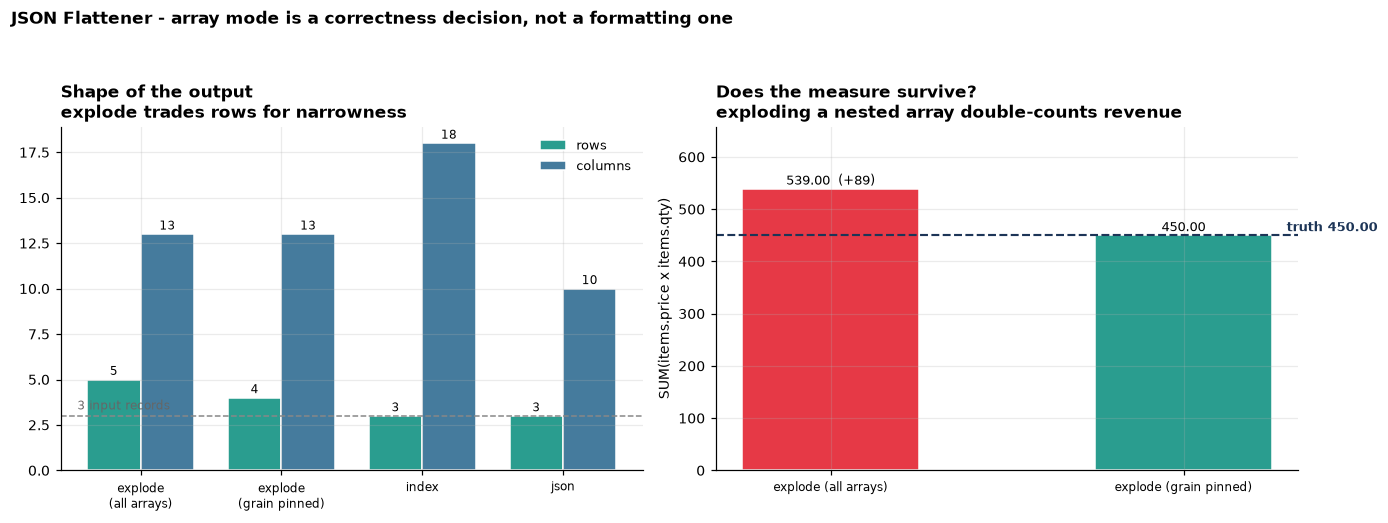

In [8]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True, "grid.alpha": 0.25,
                     "axes.spines.top": False, "axes.spines.right": False})

modes = [("explode\n(all arrays)", flatten(SAMPLE_ORDERS, array_mode="explode")),
         ("explode\n(grain pinned)", flatten(SAMPLE_ORDERS, array_mode="explode",
                                             explode_paths=["items"])),
         ("index", flatten(SAMPLE_ORDERS, array_mode="index")),
         ("json", flatten(SAMPLE_ORDERS, array_mode="json"))]

names = [m[0] for m in modes]
rowc = [m[1][1].output_rows for m in modes]
colc = [m[1][1].columns for m in modes]


def revenue(rows):
    if "items.price" not in (rows[0] if rows else {}):
        return None
    return sum((r.get("items.price") or 0) * (r.get("items.qty") or 0) for r in rows)


revs = [revenue(m[1][0]) for m in modes]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.6))

x = np.arange(len(names))
w = 0.38
ax1.bar(x - w / 2, rowc, w, label="rows", color="#2a9d8f", edgecolor="white")
ax1.bar(x + w / 2, colc, w, label="columns", color="#457b9d", edgecolor="white")
ax1.axhline(len(SAMPLE_ORDERS), ls="--", lw=1, color="#888")
ax1.text(-0.45, len(SAMPLE_ORDERS) + 0.35, f"{len(SAMPLE_ORDERS)} input records",
         fontsize=8, color="#666")
ax1.set_xticks(x)
ax1.set_xticklabels(names, fontsize=8)
ax1.set_title("Shape of the output\nexplode trades rows for narrowness",
              loc="left", fontweight="bold")
ax1.legend(frameon=False, fontsize=8.5)
for xi, (r, c) in enumerate(zip(rowc, colc)):
    ax1.text(xi - w / 2, r + 0.25, str(r), ha="center", fontsize=8)
    ax1.text(xi + w / 2, c + 0.25, str(c), ha="center", fontsize=8)

plot_names = [n.replace("\n", " ") for n, rv in zip(names, revs) if rv is not None]
plot_revs = [rv for rv in revs if rv is not None]
colors = ["#e63946" if abs(rv - truth) > 1e-9 else "#2a9d8f" for rv in plot_revs]
bars = ax2.bar(plot_names, plot_revs, color=colors, edgecolor="white", width=0.5)
ax2.axhline(truth, ls="--", lw=1.4, color="#1d3557")
ax2.text(len(plot_revs) - 0.45, truth + 8, f"truth {truth:.2f}", fontsize=8.5,
         color="#1d3557", ha="right", fontweight="bold")
for b, rv in zip(bars, plot_revs):
    off = f"  ({rv - truth:+.0f})" if abs(rv - truth) > 1e-9 else ""
    ax2.text(b.get_x() + b.get_width() / 2, rv + 8, f"{rv:.2f}{off}", ha="center", fontsize=8.5)
ax2.set_ylabel("SUM(items.price x items.qty)")
ax2.set_ylim(0, max(plot_revs) * 1.22)
ax2.tick_params(axis="x", labelsize=8)
ax2.set_title("Does the measure survive?\nexploding a nested array double-counts revenue",
              loc="left", fontweight="bold")

fig.suptitle("JSON Flattener - array mode is a correctness decision, not a formatting one",
             fontsize=11, fontweight="bold", x=0.005, ha="left", y=1.02)
fig.tight_layout(rect=(0, 0, 1, 0.97))
fig.savefig("json_flatten.png", dpi=150, bbox_inches="tight")
plt.show()

## Summary

| Mode | Rows (from 3) | Columns | SUM(revenue) |
|---|---|---|---|
| `explode` all arrays | 5 | 13 | **539.00** ❌ (+89.00) |
| `explode` grain pinned | 4 | 13 | **450.00** ✅ |
| `index` | 3 | 18 | 450.00 (first element only in that column set) |
| `json` | 3 | 10 | n/a - array kept whole |

**The takeaway:** array mode is a **correctness** decision, not a formatting preference. The
default that looks most natural - explode everything - silently inflated revenue by 20% on a
three-record sample, and nothing in the output said so. Name the grain, and have the flattener
tell you when more than one array level exploded.

The other two things worth carrying over: ragged records need a **union** of columns with a count
of what was missing (a path absent in 3 of 10,000 rows is an optional field; absent in 6,000 is a
schema change nobody mentioned), and type conflicts should **widen to text with an annotation**
rather than reject the batch.

## Try your own payload

In [9]:
# --- paste your own nested JSON -----------------------------------------
MY_JSON = """
[
  {"id": 1, "user": {"name": "A", "roles": ["admin", "dev"]}, "score": 10},
  {"id": 2, "user": {"name": "B"}, "score": 20, "extra": true}
]
"""

my_records = json.loads(MY_JSON)
for mode, kw in (("explode", {}), ("json", {})):
    rows_m, st_m = flatten(my_records, array_mode=mode, **kw)
    print(f"{mode:>8}: {st_m.output_rows} rows, {st_m.columns} cols, "
          f"ragged={list(st_m.ragged_paths)}")
    if st_m.fanout_warning:
        print("         ", st_m.fanout_warning)

rows_m, _ = flatten(my_records, array_mode="explode")
print()
print(pd.DataFrame(rows_m).to_string(index=False))
print()
print(to_ddl(rows_m, "my_table"))

 explode: 3 rows, 5 cols, ragged=['user.roles', 'extra']
    json: 2 rows, 5 cols, ragged=['user.roles', 'extra']

 id user.name user.roles  score extra
  1         A      admin     10  None
  1         A        dev     10  None
  2         B       None     20  True

CREATE TABLE my_table (
  "id" BIGINT NOT NULL,
  "user.name" VARCHAR NOT NULL,
  "user.roles" VARCHAR,
  "score" BIGINT NOT NULL,
  "extra" BOOLEAN
);


---

**Day 128** of the daily FDE build - **Data Engineering Pro** line.

Companions: **Day 98** [`schema-registry`](../schema-registry) (register the shape this infers),
**Day 2** [`schema-diff`](../../data-infra-toolkit/schema-diff) (catch it when the shape changes),
**Day 100** [`data-diff`](../../data-quality-governance/data-diff).

```bash
pip install -r requirements.txt
streamlit run app.py     # paste JSON, pick a mode, get rows + DDL
python flatten.py        # CLI, all three modes + the fan-out check
```

← [Back to the portfolio](https://github.com/phoebefu6/phoebe-the-builder/tree/main/data-engineering-pro/json-flattener)